**05_MobileNetV2_TransferLearning**

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

from tensorflow.keras import layers
from tensorflow.keras import models

from tensorflow.keras.applications import MobileNetV2

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau
)

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


In [ ]:
DATASET_PATH = Path(
    "/content/drive/MyDrive/Dataset ML/Dataset_Split"
)

IMG_SIZE = (256, 256)

BATCH_SIZE = 32

print(DATASET_PATH.exists())

True


In [ ]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH / "train",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH / "validation",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH / "test",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 700 files belonging to 2 classes.
Found 150 files belonging to 2 classes.
Found 150 files belonging to 2 classes.


In [ ]:
print(train_ds.class_names)

['Slingbag', 'Totebag']


In [ ]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

print("Data augmentation siap")

Data augmentation siap


In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(
    buffer_size=AUTOTUNE
)

val_ds = val_ds.prefetch(
    buffer_size=AUTOTUNE
)

test_ds = test_ds.prefetch(
    buffer_size=AUTOTUNE
)

print("Prefetch aktif")

Prefetch aktif


In [ ]:
base_model = MobileNetV2(
    input_shape=(256, 256, 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

print("Base model siap")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Base model siap


In [ ]:
inputs = tf.keras.Input(
    shape=(256, 256, 3)
)

x = data_augmentation(inputs)

x = tf.keras.applications.mobilenet_v2.preprocess_input(x)

x = base_model(
    x,
    training=False
)

x = layers.GlobalAveragePooling2D()(x)

x = layers.Dropout(0.3)(x)

outputs = layers.Dense(
    1,
    activation="sigmoid"
)(x)

model = tf.keras.Model(
    inputs,
    outputs
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 8, 8, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print("Model berhasil dikompilasi")

Model berhasil dikompilasi


In [ ]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=3,
    verbose=1
)

checkpoint = ModelCheckpoint(
    "/content/drive/MyDrive/Dataset ML/mobilenetv2_best.keras",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

In [ ]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[
        early_stop,
        reduce_lr,
        checkpoint
    ]
)

Epoch 1/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6797 - loss: 0.5958
Epoch 1: val_accuracy improved from None to 0.89333, saving model to /content/drive/MyDrive/Dataset ML/mobilenetv2_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Dataset ML/mobilenetv2_best.keras
22/22 ━━━━━━━━━━━━━━━━━━━━ 76s 3s/step - accuracy: 0.7529 - loss: 0.5122 - val_accuracy: 0.8933 - val_loss: 0.3375 - learning_rate: 0.0010
Epoch 2/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9044 - loss: 0.2907
Epoch 2: val_accuracy improved from 0.89333 to 0.95333, saving model to /content/drive/MyDrive/Dataset ML/mobilenetv2_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Dataset ML/mobilenetv2_best.keras
22/22 ━━━━━━━━━━━━━━━━━━━━ 86s 3s/step - accuracy: 0.9100 - loss: 0.2672 - val_accuracy: 0.9533 - val_loss: 0.2038 - learning_rate: 0.0010
Epoch 3/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9489 - loss: 0.1963
Epoch 3: val_accuracy improved fro

In [ ]:
test_loss, test_acc = model.evaluate(
    test_ds
)

print(f"Test Accuracy : {test_acc*100:.2f}%")
print(f"Test Loss     : {test_loss:.4f}")

5/5 ━━━━━━━━━━━━━━━━━━━━ 15s 3s/step - accuracy: 1.0000 - loss: 0.0400
Test Accuracy : 100.00%
Test Loss     : 0.0400


In [ ]:
y_true = np.concatenate(
    [y for x, y in test_ds],
    axis=0
)

y_pred_prob = model.predict(test_ds)

y_pred = (
    y_pred_prob > 0.5
).astype(int).flatten()

5/5 ━━━━━━━━━━━━━━━━━━━━ 13s 2s/step


In [ ]:
print(
    classification_report(
        y_true,
        y_pred,
        target_names=[
            "Slingbag",
            "Totebag"
        ]
    )
)

              precision    recall  f1-score   support

    Slingbag       1.00      1.00      1.00        75
     Totebag       1.00      1.00      1.00        75

    accuracy                           1.00       150
   macro avg       1.00      1.00      1.00       150
weighted avg       1.00      1.00      1.00       150



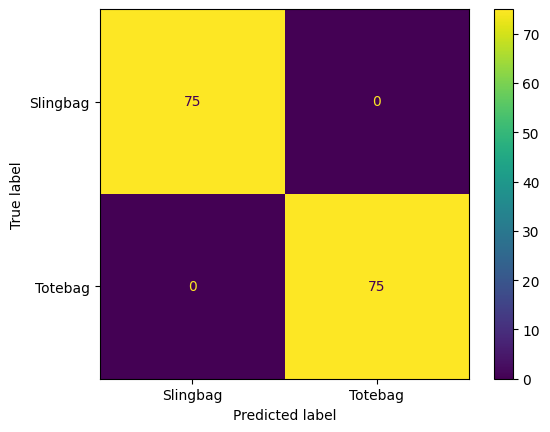

In [ ]:
cm = confusion_matrix(
    y_true,
    y_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "Slingbag",
        "Totebag"
    ]
)

disp.plot()

plt.show()

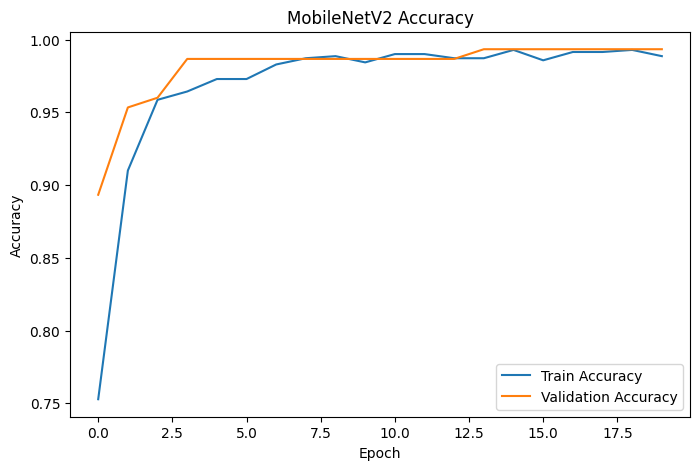

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(
    history.history['accuracy'],
    label='Train Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.title('MobileNetV2 Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

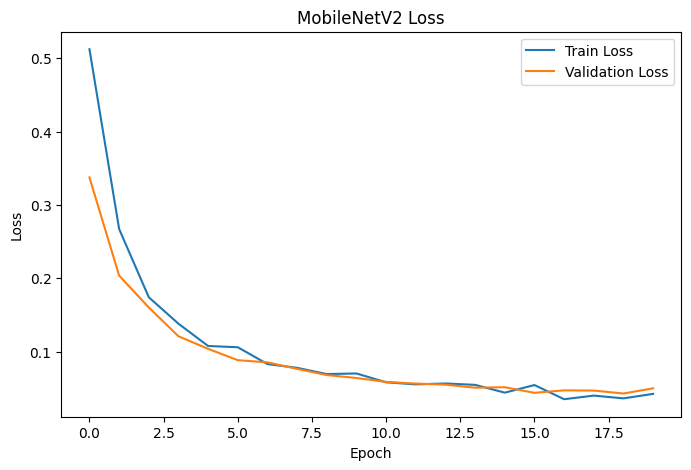

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(
    history.history['loss'],
    label='Train Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.title('MobileNetV2 Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()